# Model Selection Criterion

The final model was selected primarily based on MdAPE, with R² used as a secondary metric. Since the objective of this project is to provide accurate house price predictions for individual properties, minimizing the typical prediction error is considered more important than achieving the highest explained variance. Therefore, Random Forest was chosen as the final model because it achieved the lowest MdAPE while maintaining competitive R² performance.

# 1. Load the dataset

In [102]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,6500.0,33.475311,-117.708995,1500.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
1,1,0,1800000.0,33.899427,-117.977995,3546.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
2,1,0,1200000.0,34.095980,-118.221993,1162.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
3,1,1,3200.0,33.773119,-116.343788,1873.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,0,0,False,False,False,False,False,False,True
4,1,0,1425000.0,33.884526,-117.778002,1672.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204344,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
204345,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
204346,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,False,False,False,True,False,False,False
204347,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False


In [103]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204349 entries, 0 to 204348
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           204349 non-null  int64  
 1   PoolPrivateYN                    204349 non-null  int64  
 2   ClosePrice                       204349 non-null  float64
 3   Latitude                         204349 non-null  float64
 4   Longitude                        204349 non-null  float64
 5   LivingArea                       204349 non-null  float64
 6   MLSAreaMajor                     204349 non-null  object 
 7   CountyOrParish                   204349 non-null  object 
 8   ParkingTotal                     204349 non-null  float64
 9   PropertySubType                  204349 non-null  object 
 10  LotSizeAcres                     204349 non-null  float64
 11  YearBuilt                        204349 non-null  float64
 12  St

feature engineering

In [104]:
data_clean_2=data_clean.copy()
data_clean_2["BedBathRatio"]= np.where(data_clean_2["BathroomsTotalInteger"] == 0,0, data_clean_2["BedroomsTotal"] / data_clean_2["BathroomsTotalInteger"])
data_clean_2["Years"]=2026-data_clean_2["YearBuilt"]

Adding more detailed geographic layer using school districts

In [105]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [106]:
#points from the data
points=gpd.GeoDataFrame(data_clean_2,geometry=gpd.points_from_xy(data_clean_2["Longitude"],data_clean_2["Latitude"]), crs="EPSG:4326")
districts_filter = districts_filter.to_crs("EPSG:4326")
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join
points.drop(columns=["index_right","OBJECTID","FedID"])#drop unrelated feature
points=points.dropna()

In [107]:
points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 76191 entries, 2 to 204348
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           76191 non-null  int64   
 1   PoolPrivateYN                    76191 non-null  int64   
 2   ClosePrice                       76191 non-null  float64 
 3   Latitude                         76191 non-null  float64 
 4   Longitude                        76191 non-null  float64 
 5   LivingArea                       76191 non-null  float64 
 6   MLSAreaMajor                     76191 non-null  object  
 7   CountyOrParish                   76191 non-null  object  
 8   ParkingTotal                     76191 non-null  float64 
 9   PropertySubType                  76191 non-null  object  
 10  LotSizeAcres                     76191 non-null  float64 
 11  YearBuilt                        76191 non-null  float64 
 12  

# 2. Test train valid split¶

In [108]:
X=12 # past month
months = sorted(points["date_ym"].unique())
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2025-07-01    5882
2026-04-01    5822
2026-05-01    5768
2025-08-01    5743
2025-10-01    5731
2026-03-01    5715
2025-09-01    5577
2025-12-01    5132
2025-11-01    4771
2026-02-01    4523
2026-01-01    4153
Name: count, dtype: int64
date_ym
2026-06-01    6044
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 58817 entries, 30699 to 187832
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           58817 non-null  int64   
 1   PoolPrivateYN                    58817 non-null  int64   
 2   ClosePrice                       58817 non-null  float64 
 3   Latitude                         58817 non-null  float64 
 4   Longitude                        58817 non-null  float64 
 5   LivingArea                       58817 non-null  float64 
 6   MLSAreaMajor                     58817 non-null  object  
 7   CountyOrParish 

In [109]:
# remove outliers
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

In [110]:
# convert category feature
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [111]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

In [112]:
#change the col names
import re
X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns
]

In [113]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58233 entries, 30699 to 187832
Columns: 160 entries, ViewYN to LocaleDesc_Other
dtypes: bool(101), float64(51), int64(8)
memory usage: 32.3 MB


# 3. Comparsion between different models

In [114]:
results=[]

## 3.1 ElasticNet --- baseline

In [115]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("-------------- ElasticNet -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"ElasticNet",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

-------------- ElasticNet -------------
MdAPE (%): 32.9274%
MAPE (%): 2179.3723%
R²   : -0.5648
MAE  : 347199.8244
MSE  : 2064798236125.2278
RMSE : 1436940.5820


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.953e+15, tolerance: 3.470e+12
  model = cd_fast.enet_coordinate_descent(


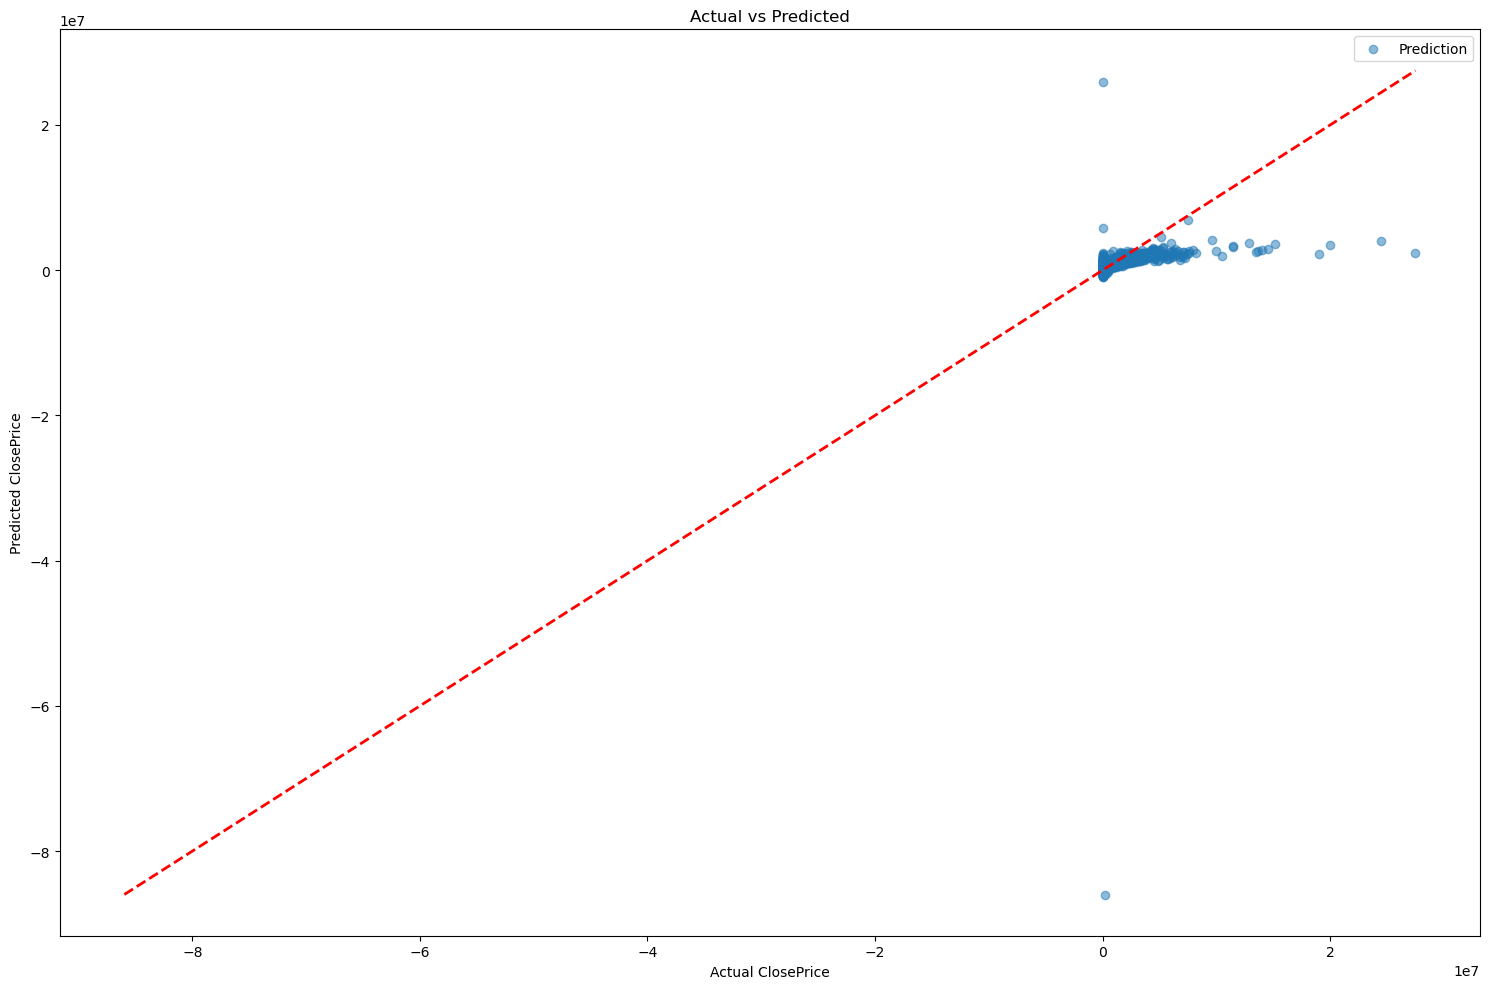

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 3.2 Decesion tree¶

In [117]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
print("-------------- Decesion tree -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
results.append({
    "model":"Decesion tree",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

-------------- Decesion tree -------------
MdAPE (%): 14.6602%
MAPE (%): 43.9824%
R²   : 0.6446
MAE  : 194431.0412
MSE  : 468984833016.9718
RMSE : 684824.6732


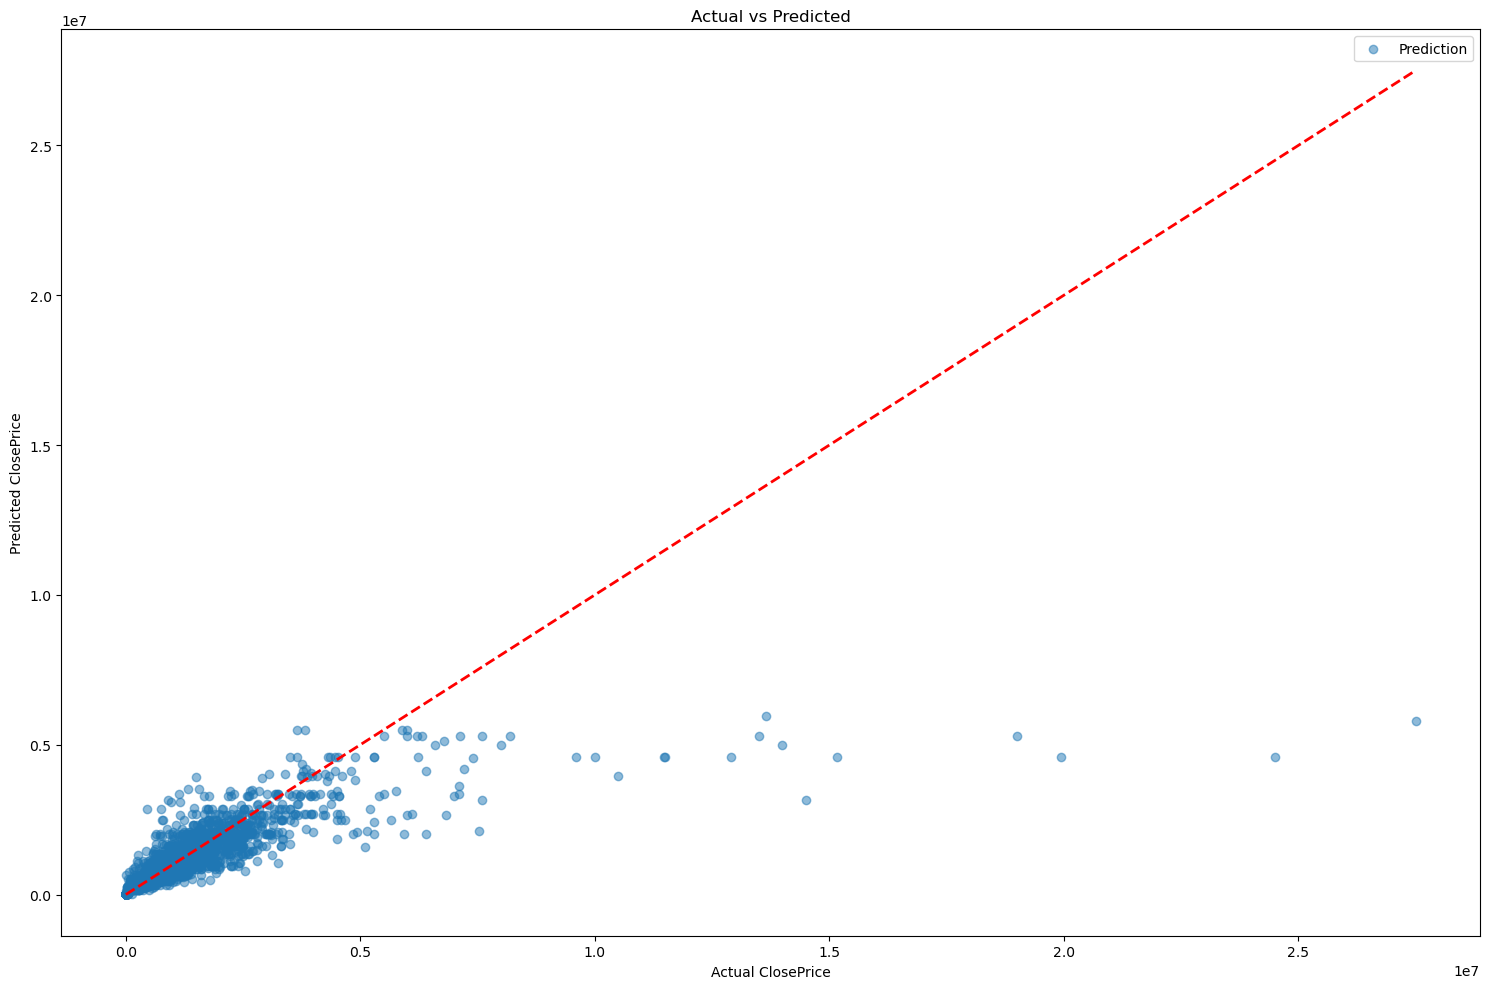

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 3.3 Random forest

In [119]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("-------------- Random forest -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
results.append({
    "model":"Random forest",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

-------------- Random forest -------------
MdAPE (%): 9.1347%
MAPE (%): 34.7750%
R²   : 0.6889
MAE  : 138977.8248
MSE  : 410503540580.8824
RMSE : 640705.5022


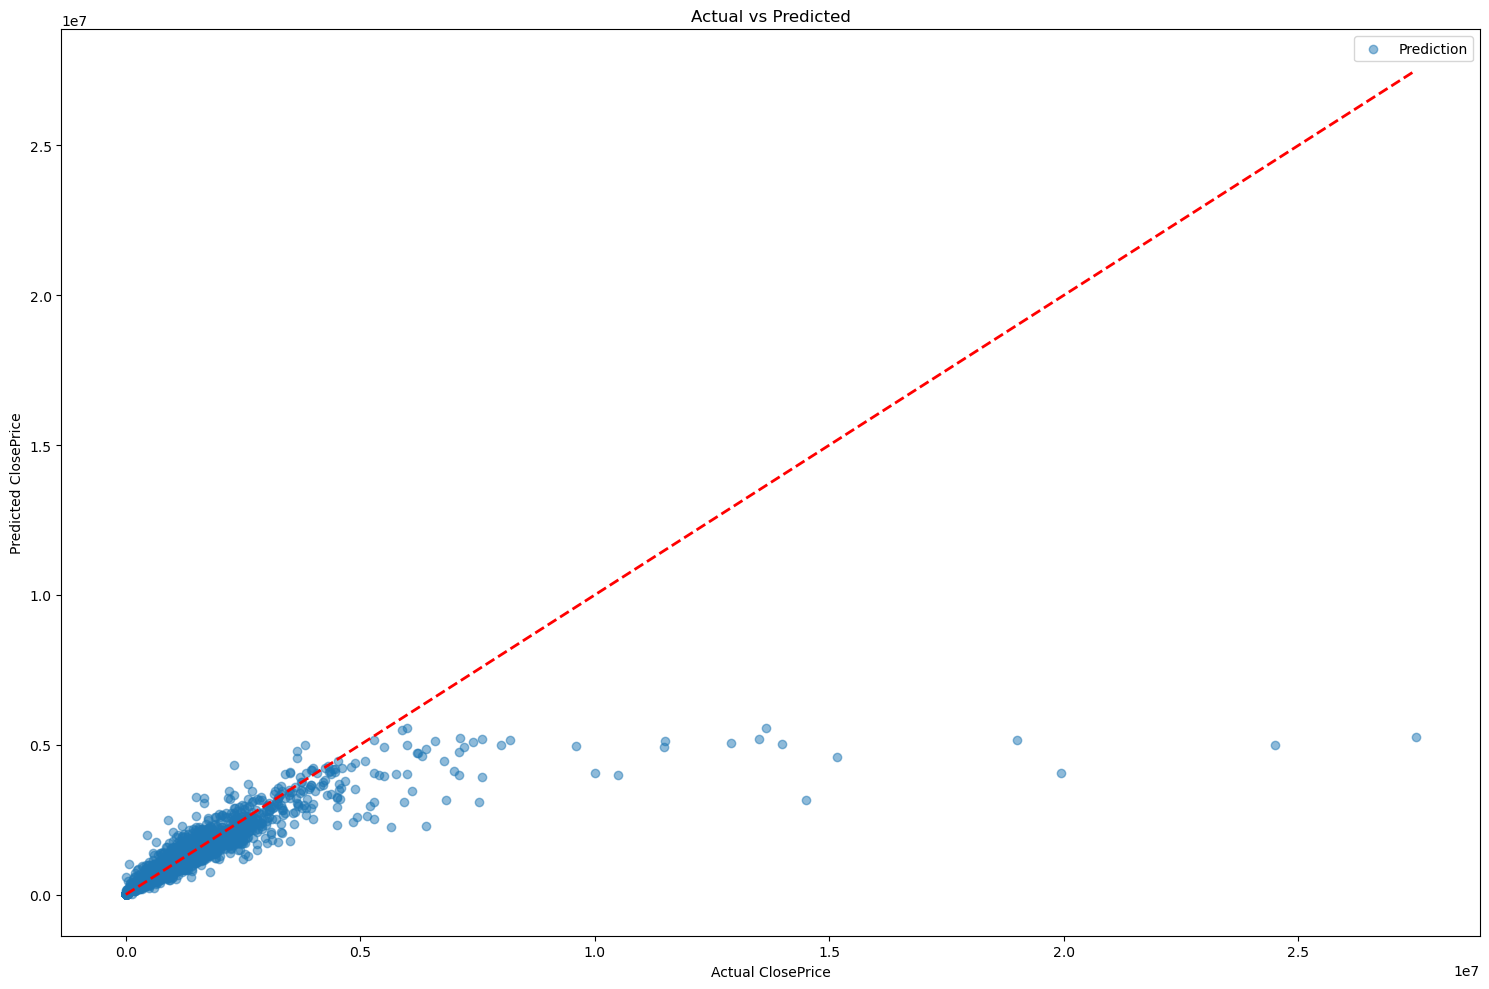

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 3.4 XGBoost

In [121]:
from xgboost import XGBRegressor

model =  XGBRegressor(
    n_estimators=243,
    learning_rate=0.03574013578339181,
    max_depth=18,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("-------------- XGBoost -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
results.append({
    "model":"XGBoost",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

-------------- XGBoost -------------
MdAPE (%): 11.8598%
MAPE (%): 43.5683%
R²   : 0.6918
MAE  : 134340.3082
MSE  : 406641692511.4814
RMSE : 637684.6341


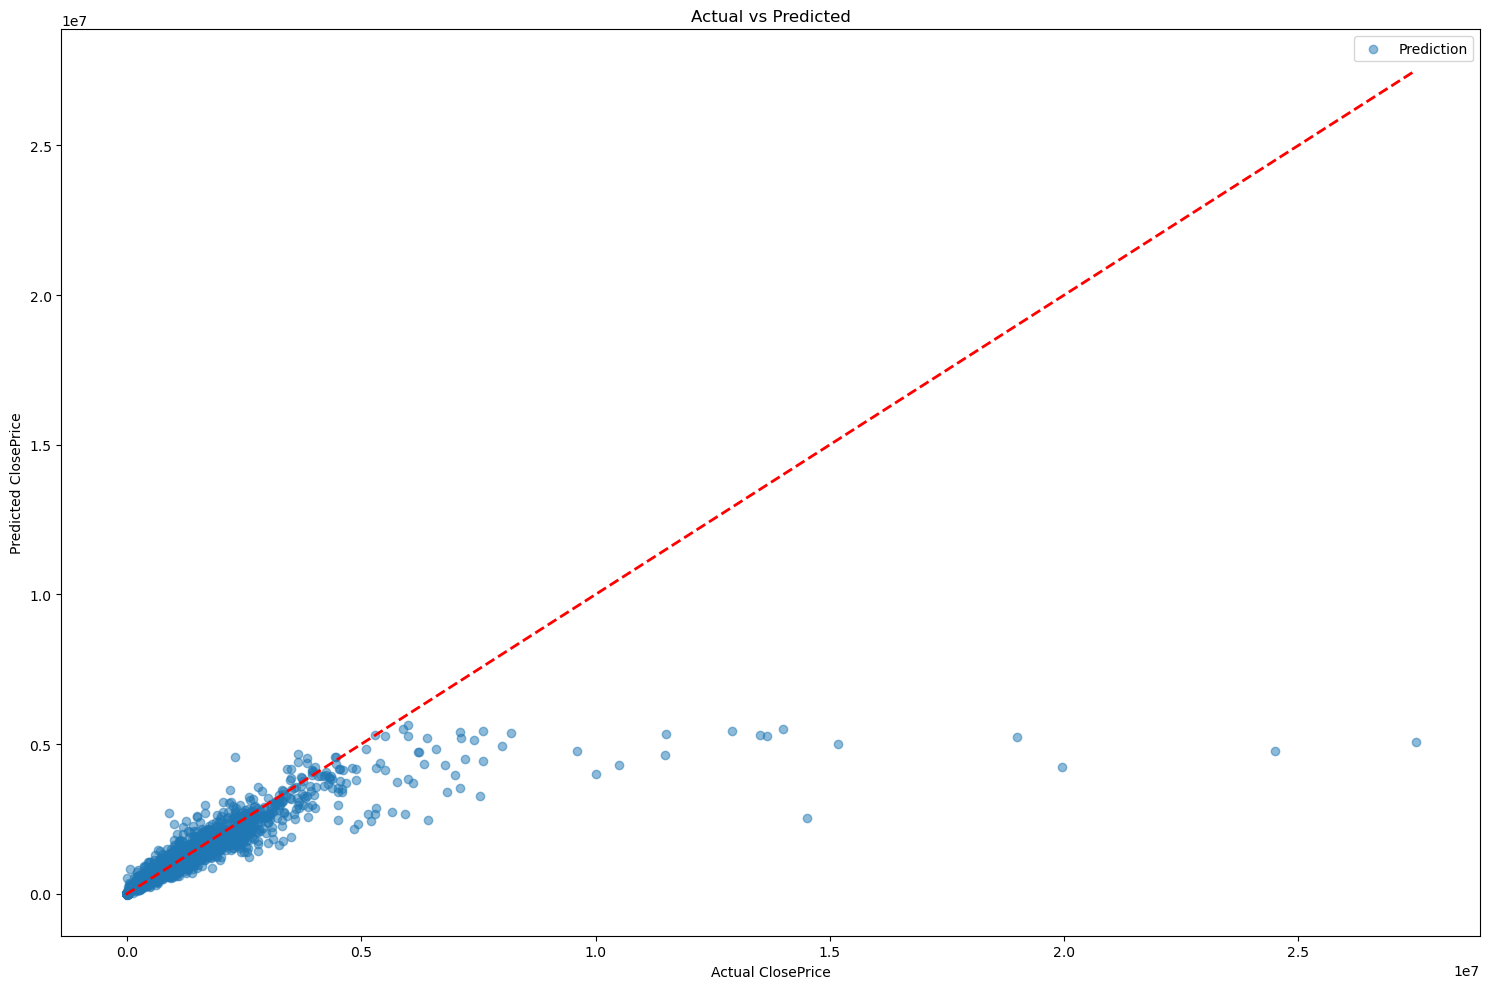

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 3.5 LightGBM

In [123]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=634,
    learning_rate=0.14077544525284386,
    max_depth=16,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("-------------- LightGBM -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
results.append({
    "model":"LightGBM",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5080
[LightGBM] [Info] Number of data points in the train set: 58233, number of used features: 156
[LightGBM] [Info] Start training from score 716136.241938
-------------- LightGBM -------------
MdAPE (%): 14.4368%
MAPE (%): 179.2048%
R²   : 0.7122
MAE  : 140642.2193
MSE  : 379804873463.8627
RMSE : 616283.1115


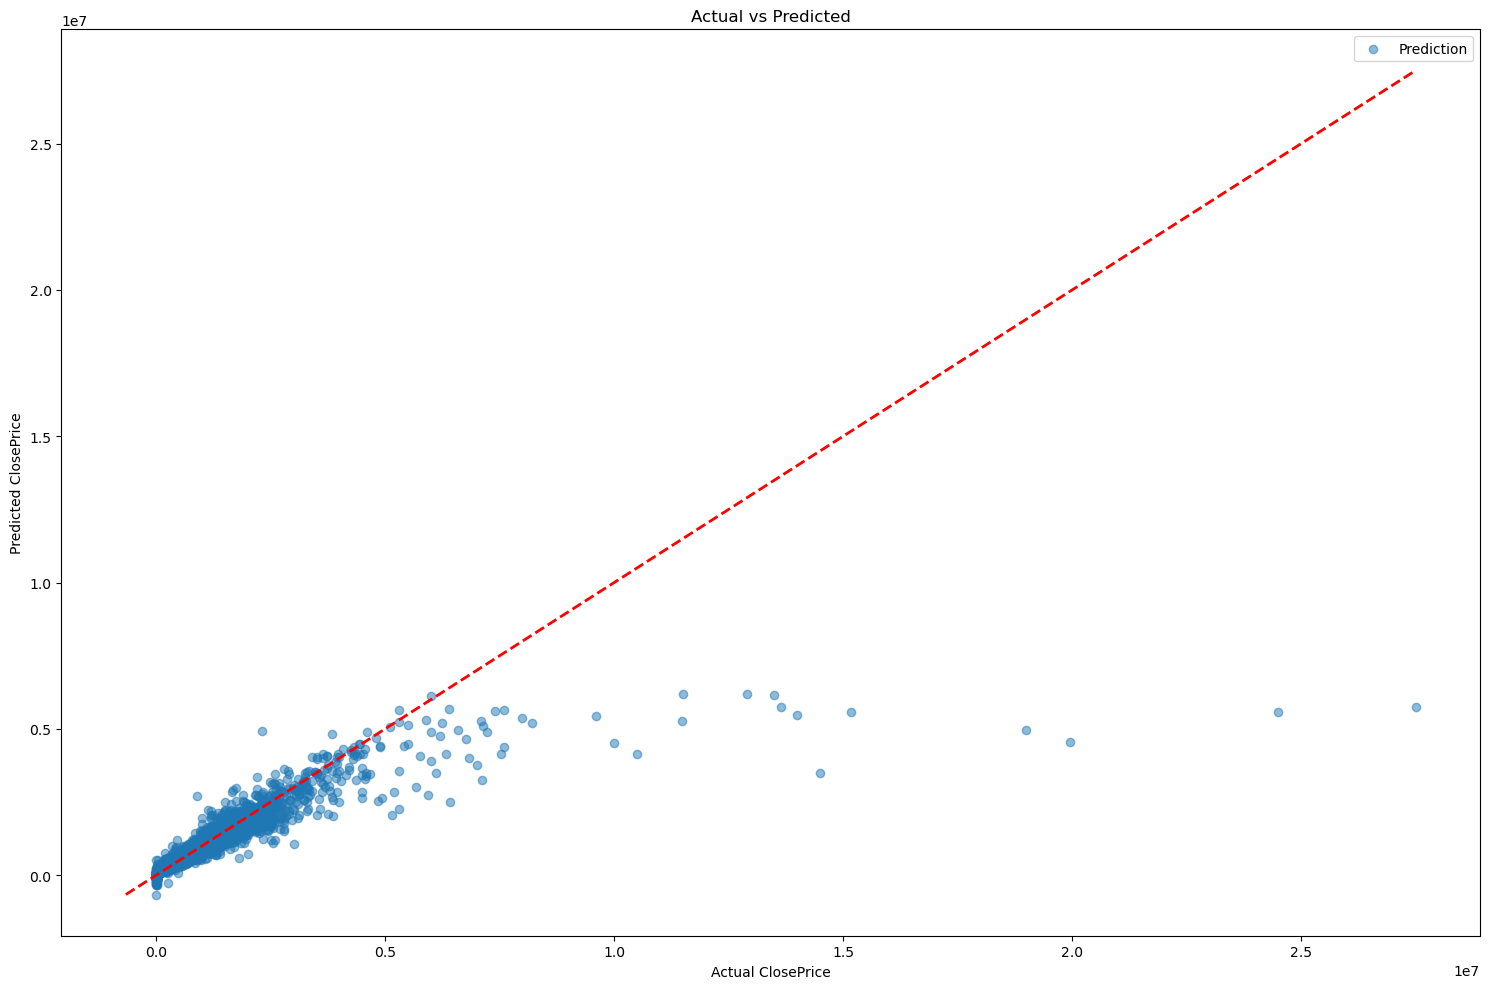

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 3.6 Plots

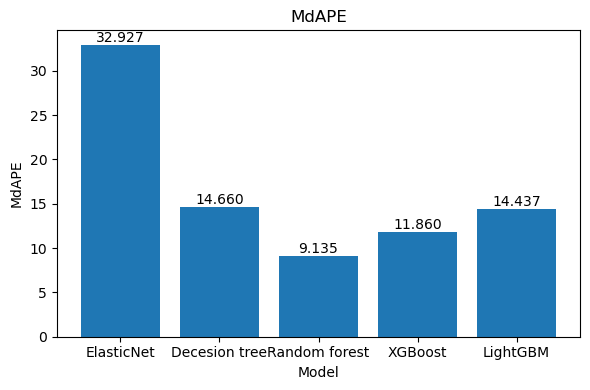

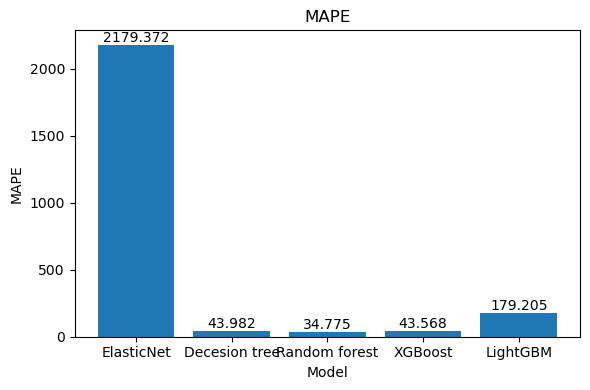

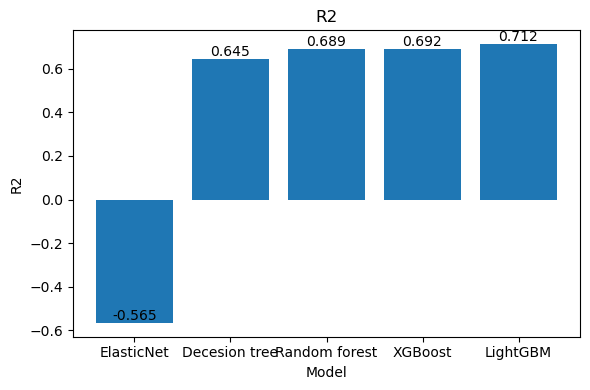

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
# results -> DataFrame
df = pd.DataFrame(results)
metrics = ["MdAPE", "MAPE", "R2"]

for metric in metrics:
    plt.figure(figsize=(6,4))

    bars = plt.bar(df["model"], df[metric])

    plt.title(f"{metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10)

    plt.tight_layout()
    plt.show()

## 3.7 Record 

In [130]:
pd.DataFrame(results).to_csv("metrics_summary.csv",index=True)

# 4. Summarize insights

Although LightGBM achieved the highest R², Random Forest produced substantially lower MdAPE and MAPE, indicating more accurate predictions for individual houses. Since the primary objective of this project is accurate house price prediction, Random Forest was selected as the final model.

In [131]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

-------------- Random forest -------------
MdAPE (%): 9.1347%
MAPE (%): 34.7750%
R²   : 0.6889
MAE  : 138977.8248
MSE  : 410503540580.8824
RMSE : 640705.5022


## 4.1  which price bands perform better

In [132]:
import pandas as pd
import numpy as np

df = pd.DataFrame({ "Actual": y_test, "Predicted": y_pred})
df["APE"] = np.abs(df["Actual"] - df["Predicted"]) / df["Actual"]
bins = [0, 300000, 600000, 1000000, np.inf]
labels = ["<300k", "300k-600k", "600k-1M", ">1M"]

df["Price Band"] = pd.cut(df["Actual"], bins=bins, labels=labels)

In [133]:
summary = df.groupby("Price Band").agg(Count=("Actual","count"), MdAPE=("APE", lambda x: np.median(x)*100), MAPE=("APE", lambda x: np.mean(x)*100))# group by  price band
summary

C:\Users\23035\AppData\Local\Temp\ipykernel_30396\3445692710.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("Price Band").agg(Count=("Actual","count"), MdAPE=("APE", lambda x: np.median(x)*100), MAPE=("APE", lambda x: np.mean(x)*100))# group by  price band


,Count,MdAPE,MAPE
Price Band,,,
<300k,1802,10.304675,85.207902
300k-600k,1317,7.924503,13.600105
600k-1M,1411,7.051630,11.313644
>1M,1514,11.669278,15.033325


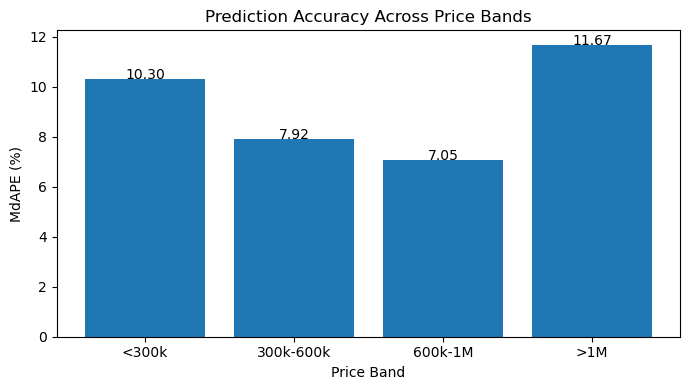

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

bars = plt.bar(summary.index.astype(str), summary["MdAPE"])

plt.ylabel("MdAPE (%)")
plt.xlabel("Price Band")
plt.title("Prediction Accuracy Across Price Bands")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 4.2 Overall model performance

In [135]:
# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print("-------------- Random forest -------------")
print(f"MdAPE (%): {mdape:.4f}%")
print(f"MAPE (%): {mape:.4f}%")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

-------------- Random forest -------------
MdAPE (%): 9.1347%
MAPE (%): 34.7750%
R²   : 0.6889
MAE  : 138977.8248
MSE  : 410503540580.8824
RMSE : 640705.5022


## 4.3 Error distribution

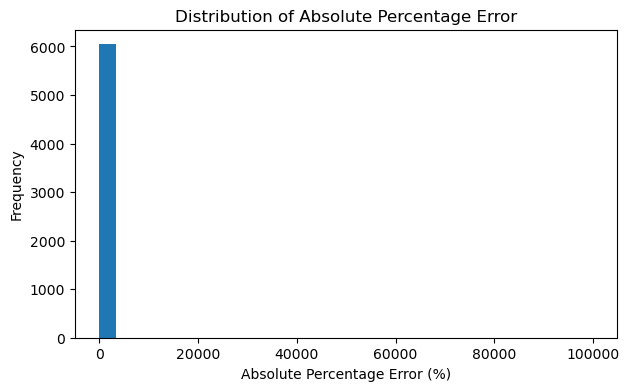

In [138]:
import matplotlib.pyplot as plt
import numpy as np

ape = np.abs(y_test - y_pred) / y_test * 100

plt.figure(figsize=(7,4))
plt.hist(ape, bins=30)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Percentage Error")

plt.show()

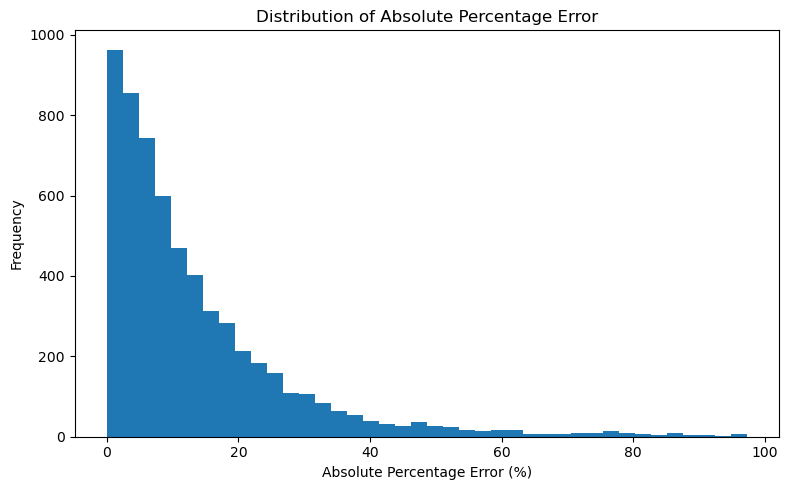

In [142]:
ape_plot = ape[ape <= 100]

plt.figure(figsize=(8,5))
plt.hist(ape_plot, bins=40)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Percentage Error")

plt.tight_layout()
plt.show()

## 4.4 Actual vs Predicted

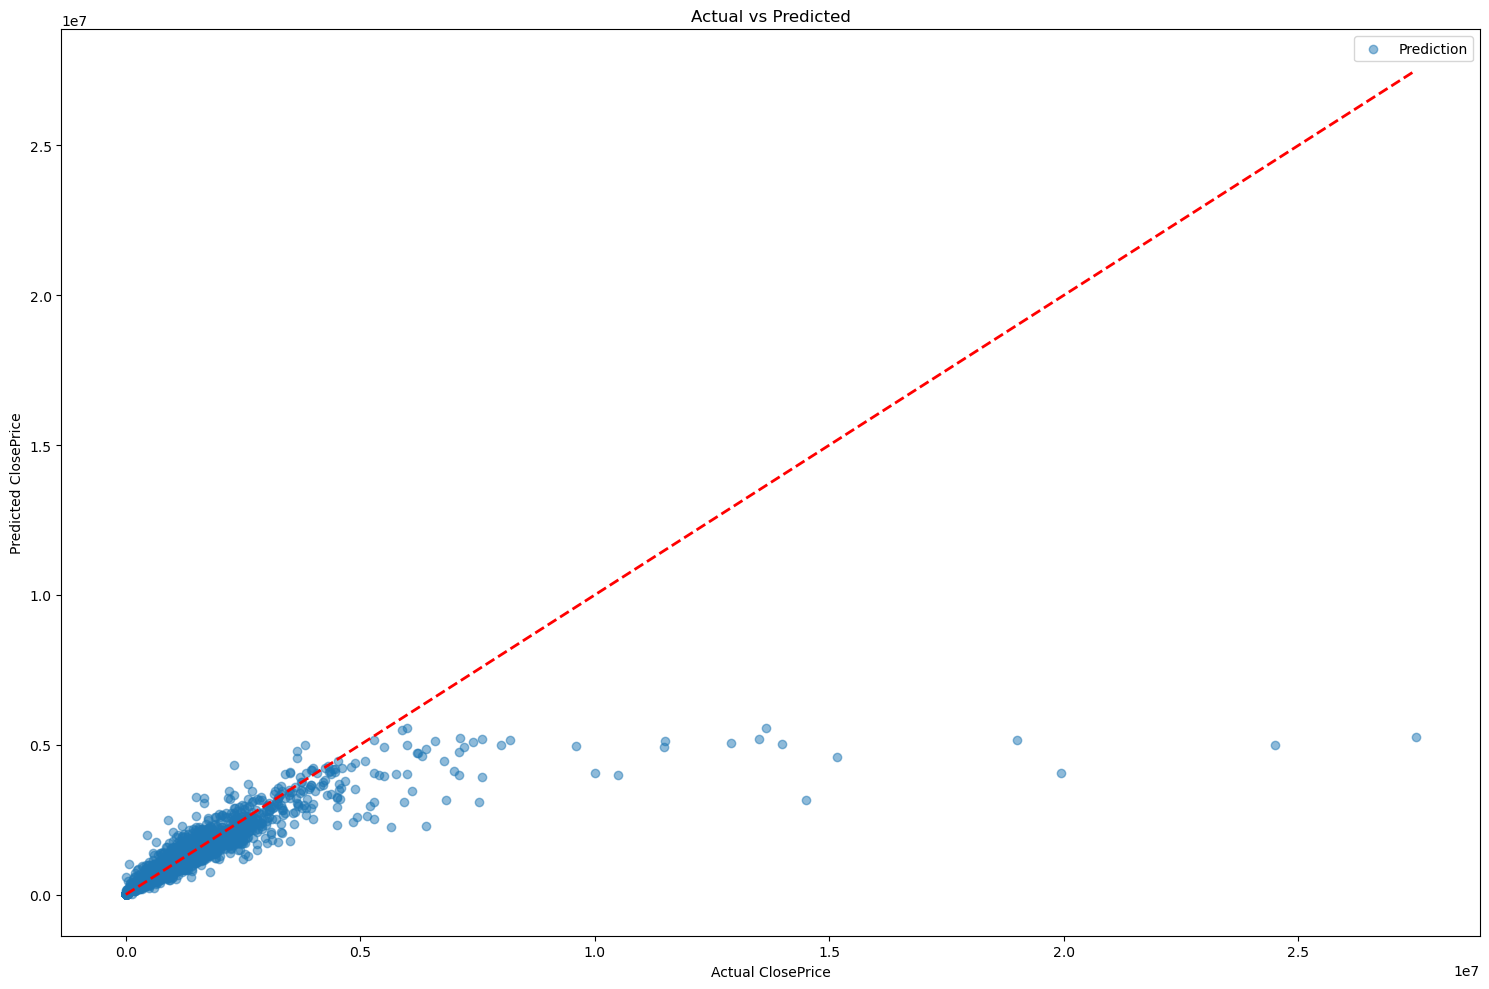

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 4.5 Feature importance

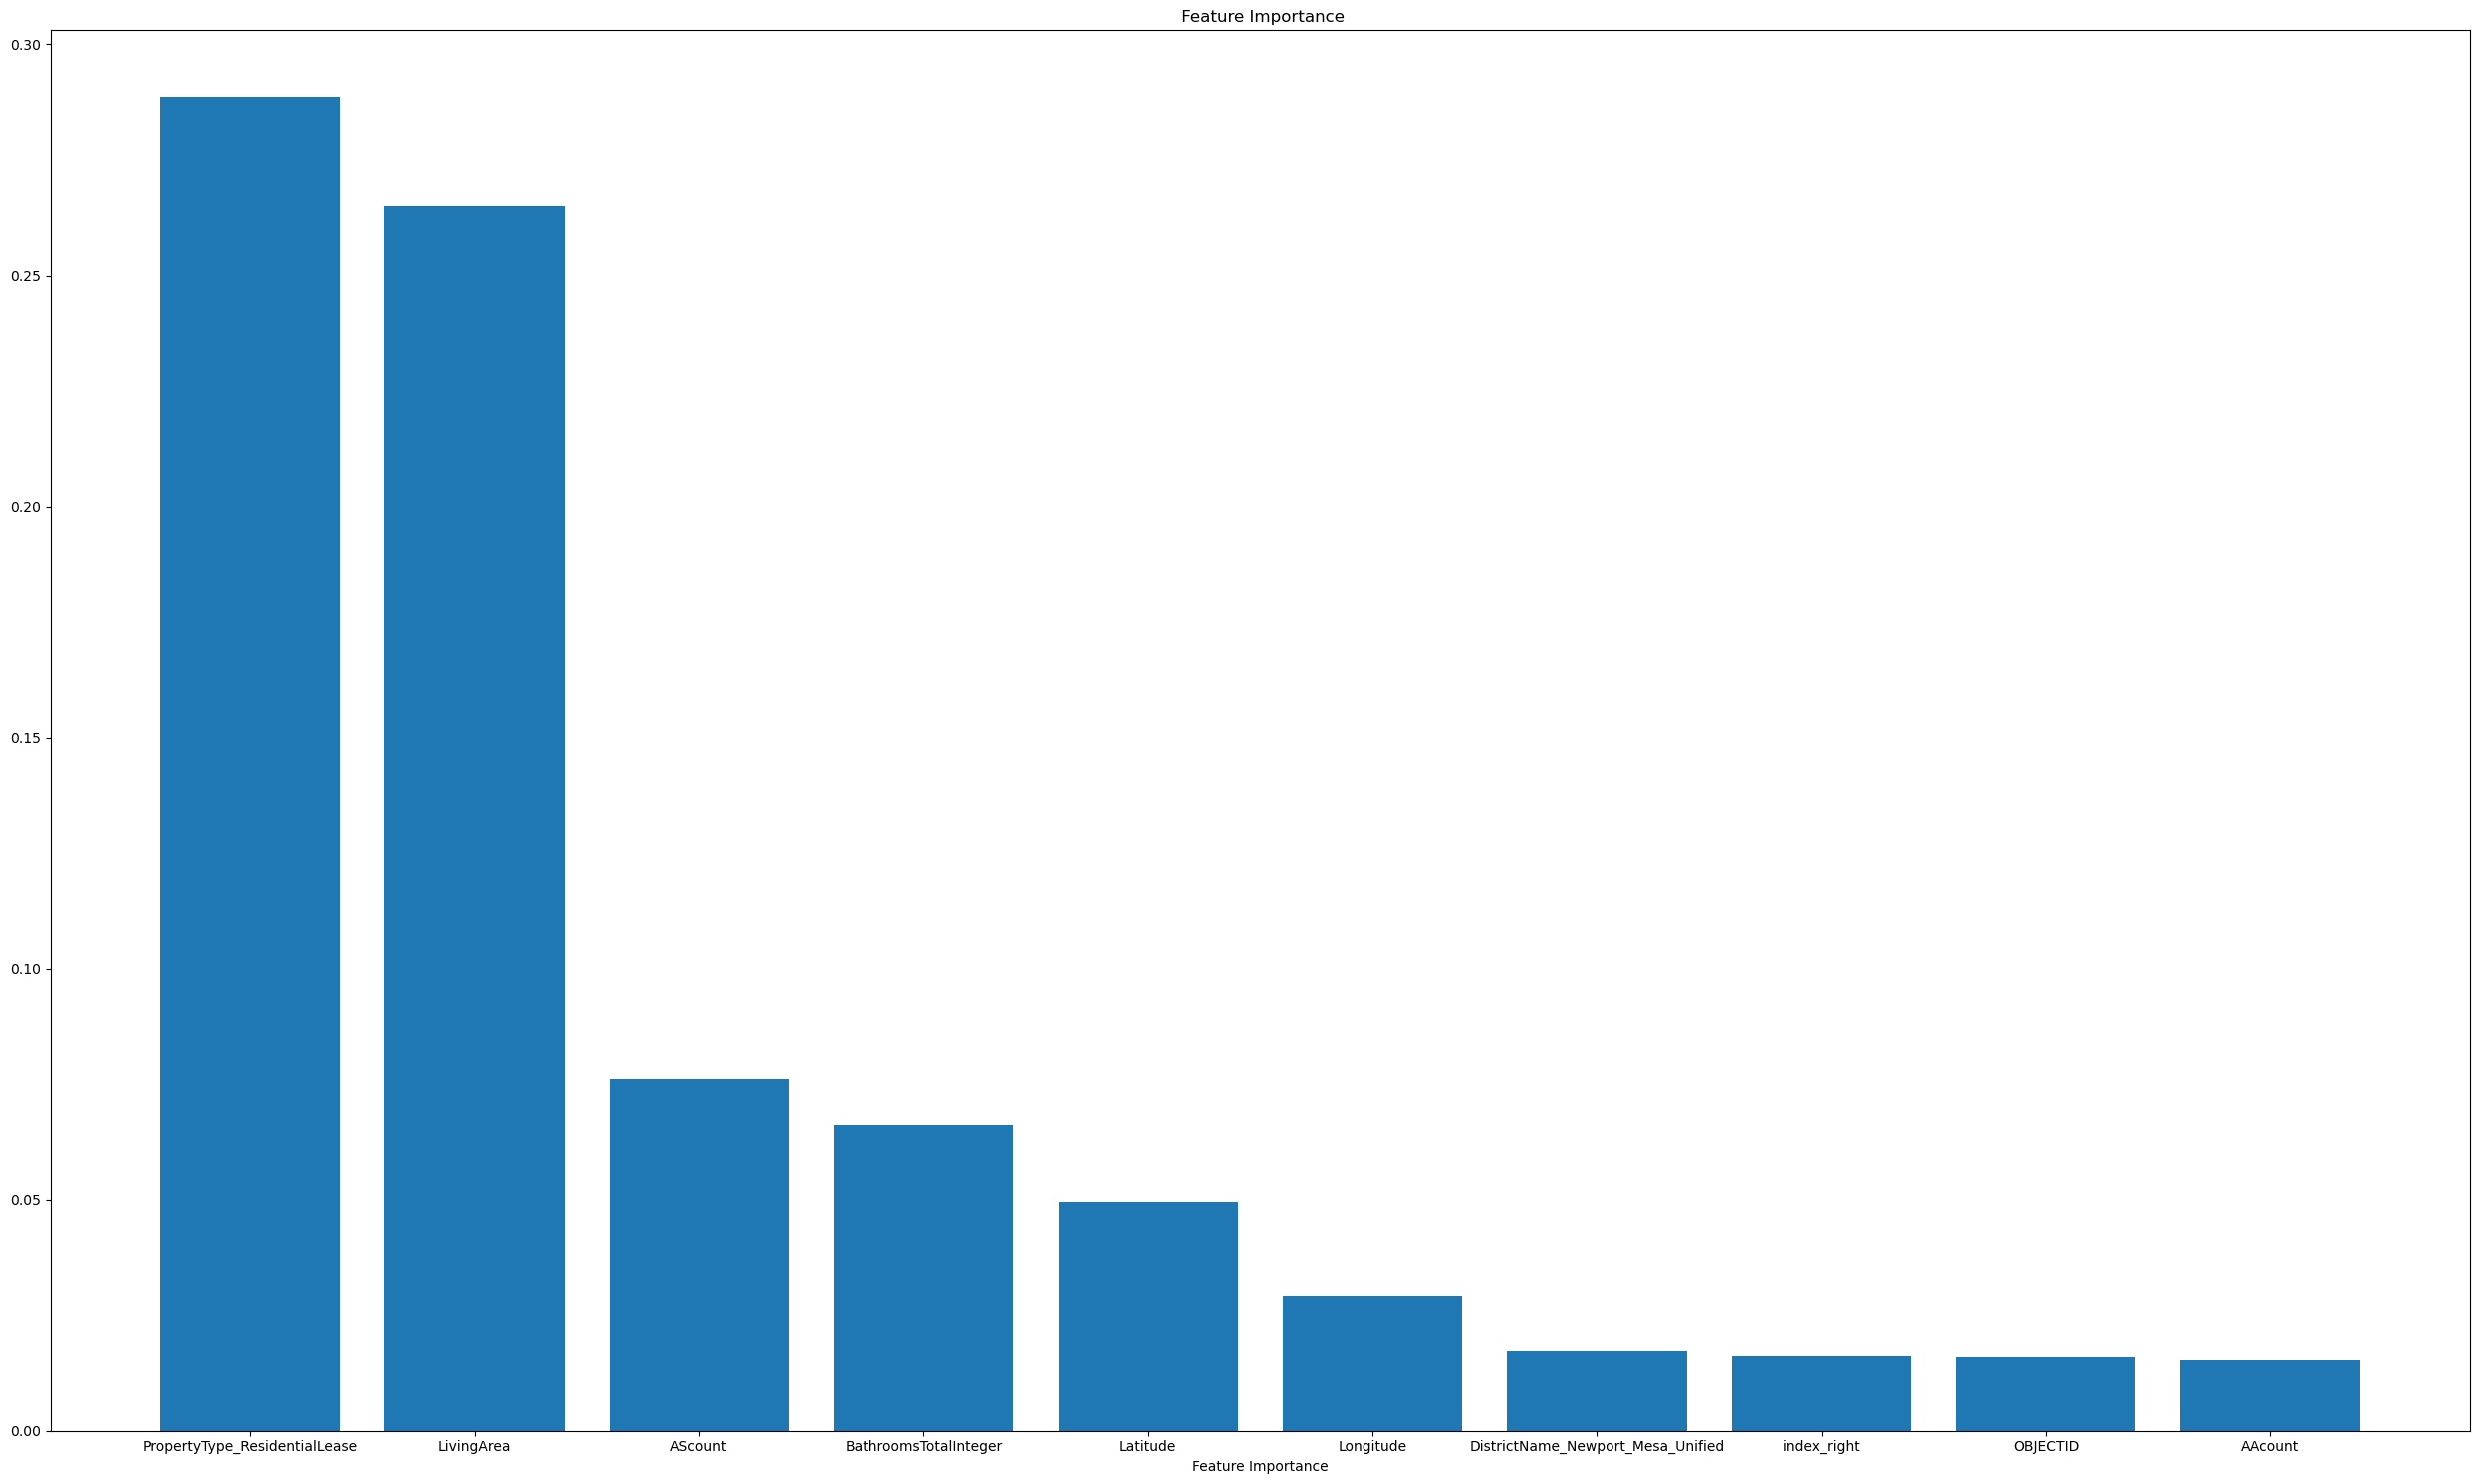

In [137]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title(" Feature Importance")
plt.tight_layout()
plt.show()

# 5. conclusion

1 According to the price band analysis, the model achieves lower MdAPE values for houses priced between **$300k$** and **$1M$**, indicating better prediction accuracy in the mid-price range. In contrast, the MdAPE is higher for houses priced below **$300k$** and above **$1M$**, suggesting that the model performs less accurately for low-priced and high-priced properties. This may be because these price ranges contain fewer training samples or exhibit greater price variability, making them more difficult for the model to learn and predict accurately.

2 The overall performance of the Random Forest model is satisfactory. The model achieved a test MdAPE of 9.13% and an R² of 0.6889. The low MdAPE indicates that the typical prediction error is relatively small, while the R² value suggests that the model explains approximately 69% of the variance in house prices. Overall, the model provides reasonably accurate predictions and demonstrates good generalization performance on the test dataset.

3 The distribution of absolute percentage error is right-skewed, with prediction errors decreasing as the error value increases. Most properties have an absolute percentage error below 40%, indicating that the model provides relatively accurate predictions for the majority of houses. Only a small proportion of properties exhibit errors greater than 40%, suggesting that large prediction errors are relatively uncommon.

4 The feature importance analysis shows that **PropertyType_ResidentialLease** and **LivingArea** are the two most influential features in the Random Forest model. Their importance scores are substantially higher than those of the remaining features, indicating that property type and living area have the greatest impact on house price prediction.
